Caso você encontre alguma dificuldade em executar no seu computador, clique aqui para abrir no colab.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ftl-brazil-2026/gis-python-basics/blob/main/python_gis_1.ipynb)

# Python para GIS — Geopandas

**Objetivo:** Ao final desta aula, você será capaz de transformar uma tabela comum (CSV) com colunas de coordenadas em um dado geoespacial, atribuir um sistema de referência, visualizar no mapa e exportar para formatos GIS.

---

## Por que Python para GIS?

Tradicionalmente, o trabalho com dados geoespaciais era feito em ferramentas de desktop como ArcGIS e QGIS. Essas ferramentas são excelentes para análise interativa, mas apresentam limitações quando precisamos:

- **Repetir** a mesma análise centenas de vezes
- **Automatizar** fluxos de trabalho
- **Integrar** dados geoespaciais com outras fontes (web, bancos de dados, APIs)
- **Documentar** e versionar cada passo do processo

O ecossistema Python para GIS resolve esses problemas. As principais bibliotecas são:

| Biblioteca | Função |
|---|---|
| **GeoPandas** | Trabalhar com dados geoespaciais como se fossem tabelas (DataFrames) |
| **Shapely** | Criar e manipular geometrias (pontos, linhas, polígonos) |
| **Fiona** | Ler e escrever arquivos geoespaciais (shapefile, GeoJSON, etc.) |
| **GDAL/Rasterio** | Trabalhar com dados raster (imagens de satélite, elevação) |
| **Folium/Leafmap** | Criar mapas interativos para a web |

Nesta aula, focaremos no **GeoPandas**, a porta de entrada do GIS em Python.

## 1.2 Revisão rápida de Pandas

O GeoPandas estende o Pandas. Vamos recapitular de forma esdrúxula:

- Um **DataFrame** é uma tabela com linhas e colunas, tal como uma planilha Excel.
- Cada coluna é uma **Series**. Conjunto de series são **Dataframe**
- Você pode ler um CSV com `pd.read_csv()`, filtrar, agrupar e transformar dados.

Vamos criar um pequeno DataFrame para relembrar:

In [1]:
import pandas as pd

dados = {
    "cidade": ["São Paulo", "Rio de Janeiro", "Belo Horizonte", "Salvador", "Brasília"],
    "populacao": [12300000, 6700000, 2500000, 2900000, 3000000],
    "latitude": [-23.55, -22.91, -19.92, -12.97, -15.78],
    "longitude": [-46.63, -43.20, -43.94, -38.50, -47.93]
}

df = pd.DataFrame(dados)
df

,cidade,populacao,latitude,longitude
0,São Paulo,12300000,-23.55,-46.63
1,Rio de Janeiro,6700000,-22.91,-43.20
2,Belo Horizonte,2500000,-19.92,-43.94
3,Salvador,2900000,-12.97,-38.50
4,Brasília,3000000,-15.78,-47.93


In [3]:
# Lembrando as operações que utilizados a todo instante 
# quando analisando os dados
print("Número de linhas e colunas:", df.shape)
print("\nNomes das colunas:", list(df.columns))
print("\nTipos de dados:")
print(df.dtypes)
print("\nPrimeiras 3 linhas:")
df.head(3)

Número de linhas e colunas: (5, 4)

Nomes das colunas: ['cidade', 'populacao', 'latitude', 'longitude']

Tipos de dados:
cidade           str
populacao      int64
latitude     float64
longitude    float64
dtype: object

Primeiras 3 linhas:


,cidade,populacao,latitude,longitude
0,São Paulo,12300000,-23.55,-46.63
1,Rio de Janeiro,6700000,-22.91,-43.20
2,Belo Horizonte,2500000,-19.92,-43.94


## Criando um CSV com coordenadas

Imagine que você fez trabalho de campo e anotou coordenadas de pontos de coleta de água em um rio. Seus dados estão assim:

In [6]:
import csv
import os

csv_path = "pontos_coleta.csv"

if not os.path.exists(csv_path):
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["id", "data", "parametro", "valor", "x", "y"])
        writer.writerow([1, "2024-01-15", "pH", 6.8, -46.63, -23.55])
        writer.writerow([2, "2024-01-15", "turbidez", 12.3, -46.64, -23.56])
        writer.writerow([3, "2024-01-15", "pH", 7.1, -46.65, -23.55])
        writer.writerow([4, "2024-01-16", "oxigenio", 5.2, -46.62, -23.54])
        writer.writerow([5, "2024-01-16", "pH", 6.9, -46.66, -23.57])
        writer.writerow([6, "2024-01-16", "turbidez", 8.7, -46.63, -23.56])

df_coleta = pd.read_csv(csv_path)
df_coleta

,id,data,parametro,valor,x,y
0,1,2024-01-15,pH,6.8,-46.63,-23.55
1,2,2024-01-15,turbidez,12.3,-46.64,-23.56
2,3,2024-01-15,pH,7.1,-46.65,-23.55
3,4,2024-01-16,oxigenio,5.2,-46.62,-23.54
4,5,2024-01-16,pH,6.9,-46.66,-23.57
5,6,2024-01-16,turbidez,8.7,-46.63,-23.56


Temos colunas `x` e `y` com as coordenadas, mas para o computador isso é apenas uma tabela comum. Precisamos dizer a ele que essas colunas representam **geometrias espaciais**.

## 1.4 Transformando em GeoDataFrame

A mágica acontece com a função `points_from_xy` do GeoPandas. Ela cria uma coluna de geometrias do tipo **ponto** a partir de colunas de longitude (x) e latitude (y).

In [7]:
import geopandas as gpd
from shapely.geometry import Point

gdf = gpd.GeoDataFrame(
    df_coleta,
    geometry=gpd.points_from_xy(df_coleta["x"], df_coleta["y"]),
)

print("Tipo do objeto:", type(gdf))
print("Geometrias criadas:")
gdf

Tipo do objeto: <class 'geopandas.geodataframe.GeoDataFrame'>
Geometrias criadas:


,id,data,parametro,valor,x,y,geometry
0,1,2024-01-15,pH,6.8,-46.63,-23.55,POINT (-46.63 -23.55)
1,2,2024-01-15,turbidez,12.3,-46.64,-23.56,POINT (-46.64 -23.56)
2,3,2024-01-15,pH,7.1,-46.65,-23.55,POINT (-46.65 -23.55)
3,4,2024-01-16,oxigenio,5.2,-46.62,-23.54,POINT (-46.62 -23.54)
4,5,2024-01-16,pH,6.9,-46.66,-23.57,POINT (-46.66 -23.57)
5,6,2024-01-16,turbidez,8.7,-46.63,-23.56,POINT (-46.63 -23.56)


In [7]:
print(gdf.crs)

None


**O que mudou?**

- Agora temos uma coluna `geometry` com objetos do tipo `Point`.
- Um `GeoDataFrame` é um `DataFrame` do Pandas **com uma coluna especial de geometria**.
- Todas as operações do Pandas continuam funcionando (filtrar, agrupar, etc.).

Vamos ver os atributos geoespaciais que ganhamos:

In [11]:
gdf.columns

Index(['id', 'data', 'parametro', 'valor', 'x', 'y', 'geometry'], dtype='str')

In [12]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         6 non-null      int64   
 1   data       6 non-null      str     
 2   parametro  6 non-null      str     
 3   valor      6 non-null      float64 
 4   x          6 non-null      float64 
 5   y          6 non-null      float64 
 6   geometry   6 non-null      geometry
dtypes: float64(3), geometry(1), int64(1), str(2)
memory usage: 468.0 bytes


In [15]:
gdf.geometry

0    POINT (-46.63 -23.55)
1    POINT (-46.64 -23.56)
2    POINT (-46.65 -23.55)
3    POINT (-46.62 -23.54)
4    POINT (-46.66 -23.57)
5    POINT (-46.63 -23.56)
Name: geometry, dtype: geometry

In [14]:
type(gdf.geometry)


geopandas.geoseries.GeoSeries

In [16]:
print(gdf.geom_type)

0    Point
1    Point
2    Point
3    Point
4    Point
5    Point
dtype: str


In [21]:
gdf['geometry']

0   -46.63
1   -46.64
2   -46.65
3   -46.62
4   -46.66
5   -46.63
dtype: float64

In [29]:
gdf.geometry.y

0   -23.55
1   -23.56
2   -23.55
3   -23.54
4   -23.57
5   -23.56
dtype: float64

In [34]:
gdf.geometry.x.iloc[5]

np.float64(-46.63)

In [17]:
print("  x =", gdf.geometry.x[0])
print("  y =", gdf.geometry.y[0])

  x = -46.63
  y = -23.55


In [30]:
print("Tipo de geometria:")
print(gdf.geom_type)
print("\nCoordenadas do primeiro ponto:")
print("  x =", gdf.geometry.x[0])
print("  y =", gdf.geometry.y[0])
print("\nLimites (bounds) de todas as geometrias:")
print(gdf.total_bounds)

Tipo de geometria:
0    Point
1    Point
2    Point
3    Point
4    Point
5    Point
dtype: str

Coordenadas do primeiro ponto:
  x = -46.63
  y = -23.55

Limites (bounds) de todas as geometrias:
[-46.66 -23.57 -46.62 -23.54]


In [35]:
gdf.total_bounds

array([-46.66, -23.57, -46.62, -23.54])

> **Atenção à ordem:** Em GIS, a convenção é **(longitude, latitude)** = **(x, y)**. Latitude é y (Norte/Sul), longitude é x (Leste/Oeste). Inverter essa ordem é um erro clássico!

In [36]:
gdf.crs

## Sistemas de Referência de Coordenadas (CRS)

Coordenadas sem um CRS são apenas números. O CRS define **como** esses números se relacionam com a superfície da Terra.

### Dois tipos fundamentais:

| Tipo | Descrição | Exemplo | Unidade |
|---|---|---|---|
| **Geográfico** | Coordenadas angulares (latitude/longitude) sobre um modelo esférico da Terra | EPSG:4326 (WGS 84) | Graus |
| **Projetado** | Coordenadas planas (x, y) em metros, resultado de projetar a esfera em um plano | EPSG:31983 (SIRGAS 2000 / UTM 23S) | Metros |

> **EPSG** é o catálogo internacional de CRSs. Cada código EPSG identifica unicamente um sistema de referência.

Nossas coordenadas estão em latitude/longitude (WGS 84), então o CRS é **EPSG:4326**. Vamos atribuí-lo:

Link maneiro: https://epsg.io/

SIRGAS2000 é o sistema geodésico de referência oficial do Brasil.

Diferença para o WGS84O WGS84 é o sistema global usado pelos aparelhos de GPS.O SIRGAS2000 é praticamente igual ao WGS84 na prática diária, mas é ajustado especificamente para a placa tectônica da América do Sul.

Baita explicação: https://www.professores.uff.br/cristiane/cartografia/

In [37]:
print("CRS atual (não definido):", gdf.crs)


CRS atual (não definido): None

CRS atribuído:
EPSG:4326


In [38]:
# set a new crs
gdf = gdf.set_crs("EPSG:4326")

gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [41]:
# vamos tentar transformar em SIRGAS2000 
gdf.to_crs("EPSG:4989")

,id,data,parametro,valor,x,y,geometry
0,1,2024-01-15,pH,6.8,-46.63,-23.55,POINT (-46.63 -23.55)
1,2,2024-01-15,turbidez,12.3,-46.64,-23.56,POINT (-46.64 -23.56)
2,3,2024-01-15,pH,7.1,-46.65,-23.55,POINT (-46.65 -23.55)
3,4,2024-01-16,oxigenio,5.2,-46.62,-23.54,POINT (-46.62 -23.54)
4,5,2024-01-16,pH,6.9,-46.66,-23.57,POINT (-46.66 -23.57)
5,6,2024-01-16,turbidez,8.7,-46.63,-23.56,POINT (-46.63 -23.56)


**A diferença entre definir e transformar:**

- `.set_crs()` → **declara** qual CRS os dados já estão usando (não altera as coordenadas).
- `.to_crs()` → **converte** as coordenadas para outro CRS (altera os valores). Veremos isso melhor na Aula 3 e na semana que vem.

## 1.6 Primeira visualização

O GeoPandas integra com Matplotlib para plotar geometrias diretamente:

<Axes: >

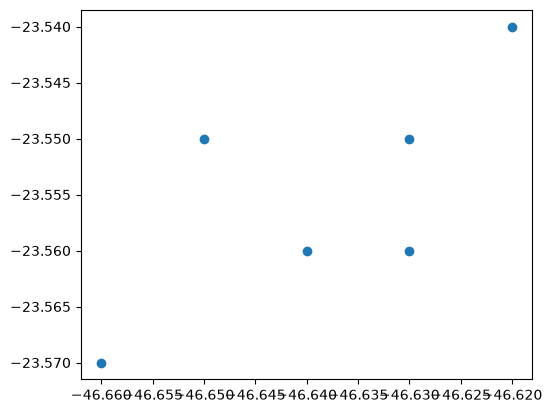

In [42]:
gdf.plot()

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

gdf.plot(
    ax=ax,
    column="parametro",
    legend=True,
    markersize=80,
    edgecolor="black",
    linewidth=0.5,
)

# for idx, row in gdf.iterrows():
#     ax.annotate(
#         f"{row['id']}: {row['valor']}",
#         (row.geometry.x, row.geometry.y),
#         xytext=(5, 5),
#         textcoords="offset points",
#         fontsize=8,
#     )

ax.set_title("Pontos de coleta — Rio Tietê", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

O `.plot()` do GeoPandas renderiza a coluna `geometry` automaticamente. Você pode colorir por uma coluna de atributo (`column=`), adicionar legenda e personalizar como qualquer gráfico Matplotlib.

## 1.7 Exportando

Agora que temos um GeoDataFrame com CRS definido, podemos salvá-lo nos formatos padrão do mundo GIS:

In [8]:
import os

os.makedirs("saida", exist_ok=True)

# formato classico que todo mundo ama 
gdf.to_file("saida/pontos_coleta.shp")
print("Shapefile salvo: saida/pontos_coleta.shp")

# melhor formato pra integrar com frontent - javascript 
gdf.to_file("saida/pontos_coleta.geojson", driver="GeoJSON")
print("GeoJSON salvo: saida/pontos_coleta.geojson")

# formato multifuncional, amo s2 s2 
gdf.to_file("saida/pontos_coleta.gpkg", driver="GPKG")
print("GeoPackage salvo: saida/pontos_coleta.gpkg")

Shapefile salvo: saida/pontos_coleta.shp
GeoJSON salvo: saida/pontos_coleta.geojson
GeoPackage salvo: saida/pontos_coleta.gpkg


/Users/macuser/Documents/UN/materials/gis-python/.venv/lib/python3.13/site-packages/pyogrio/geopandas.py:948: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
/Users/macuser/Documents/UN/materials/gis-python/.venv/lib/python3.13/site-packages/pyogrio/geopandas.py:948: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
/Users/macuser/Documents/UN/materials/gis-python/.venv/lib/python3.13/site-packages/pyogrio/geopandas.py:948: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


### Guia rápido de formatos:

| Formato | Extensão | Característica |
|---|---|---|
| **Shapefile** | `.shp` | Formato mais antigo e difundido, fundado pela ArcGIS. Na verdade são múltiplos arquivos (.shp, .shx, .dbf, .prj). Limitado a 10 caracteres no nome de colunas. |
| **GeoJSON** | `.geojson` | Baseado em JSON. Ideal para web e APIs. Um único arquivo legível por humanos. |
| **GeoPackage** | `.gpkg` | Padrão moderno da OGC. Baseado em SQLite. Suporta múltiplas camadas num só arquivo. |

> **Recomendação:** Prefira **GeoPackage** para projetos novos. Use **Shapefile** apenas quando precisar interoperar com sistemas legados. Use **GeoJSON** para aplicações web.

# Integrando Shapely e GeoPandas

## 2.8 Integrando Shapely com GeoPandas

Agora sabemos que:
- **Shapely** cria e manipula geometrias
- **GeoPandas** organiza geometrias em DataFrames

A coluna `geometry` de um GeoDataFrame é composta por objetos Shapely! Vamos criar um GeoDataFrame inteiro a partir de geometrias feitas manualmente:

In [57]:
import geopandas as gpd
from shapely.geometry import Polygon, box

zonas = gpd.GeoDataFrame({
    "nome": ["Zona Residencial", "Zona Comercial", "Zona Industrial", "Parque"],
    "densidade": ["Alta", "Média", "Baixa", "Nula"],
    "geometry": [
        box(0, 0, 6, 6),
        Polygon([(4, 2), (10, 2), (10, 5), (4, 5)]),
        Polygon([(0, 6), (5, 6), (5, 10), (0, 10)]),
        Polygon([(6, 5), (10, 5), (10, 9), (6, 9)]),
    ]
}, crs="EPSG:4326")

zonas

,nome,densidade,geometry
0,Zona Residencial,Alta,"POLYGON ((6 0, 6 6, 0 6, 0 0, 6 0))"
1,Zona Comercial,Média,"POLYGON ((4 2, 10 2, 10 5, 4 5, 4 2))"
2,Zona Industrial,Baixa,"POLYGON ((0 6, 5 6, 5 10, 0 10, 0 6))"
3,Parque,Nula,"POLYGON ((6 5, 10 5, 10 9, 6 9, 6 5))"


In [59]:
# zonas.plot()

In [68]:
zonas.geometry.iloc[0].area

36.0

In [71]:
zonas['centroid'] = zonas.geometry.apply(lambda x:x.centroid)

In [75]:
list_save =[]
for i in zonas.geometry.values:
    s = i.centroid
    list_save.append(s)

zonas['centroid2'] = list_save

In [76]:
zonas

,nome,densidade,geometry,centroid,centroid2
0,Zona Residencial,Alta,"POLYGON ((6 0, 6 6, 0 6, 0 0, 6 0))",POINT (3 3),POINT (3 3)
1,Zona Comercial,Média,"POLYGON ((4 2, 10 2, 10 5, 4 5, 4 2))",POINT (7 3.5),POINT (7 3.5)
2,Zona Industrial,Baixa,"POLYGON ((0 6, 5 6, 5 10, 0 10, 0 6))",POINT (2.5 8),POINT (2.5 8)
3,Parque,Nula,"POLYGON ((6 5, 10 5, 10 9, 6 9, 6 5))",POINT (8 7),POINT (8 7)


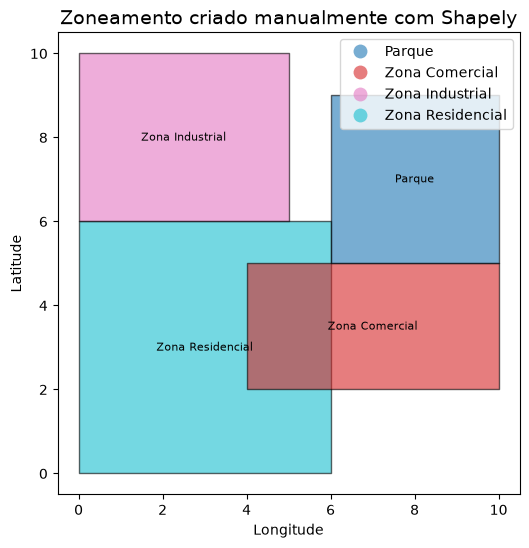

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
zonas.plot(ax=ax, 
           column="nome", 
           legend=True, 
           edgecolor="black", 
           alpha=0.6
           )

for idx, row in zonas.iterrows():
    # pega o centroid
    centro = row.geometry.centroid
    # manda escrever o tipo de zona no ponto centroid 
    ax.text(centro.x, centro.y, row["nome"], ha="center", va="center", fontsize=8)

ax.set_title("Zoneamento criado manualmente com Shapely", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.show()

In [78]:
print("Área de cada zona (em graus²):")
for idx, row in zonas.iterrows():
    print(f"  {row['nome']}: {row.geometry.area:.2f}")

print("\nInterseção entre Zona Residencial e Zona Comercial:")
inter = zonas.iloc[0].geometry.intersection(zonas.iloc[1].geometry)
print(f"  Área da interseção: {inter.area:.2f}")

Área de cada zona (em graus²):
  Zona Residencial: 36.00
  Zona Comercial: 18.00
  Zona Industrial: 20.00
  Parque: 16.00

Interseção entre Zona Residencial e Zona Comercial:
  Área da interseção: 6.00


> Muito cuidado pequeno gafanhoto quando calcular a área de uma represenção numa sistema de coordenada geográfica, sem estar projetado para a área de intereste.

In [80]:
zonas.columns

Index(['nome', 'densidade', 'geometry', 'centroid', 'centroid2'], dtype='str')

In [81]:
zonas

,nome,densidade,geometry,centroid,centroid2
0,Zona Residencial,Alta,"POLYGON ((6 0, 6 6, 0 6, 0 0, 6 0))",POINT (3 3),POINT (3 3)
1,Zona Comercial,Média,"POLYGON ((4 2, 10 2, 10 5, 4 5, 4 2))",POINT (7 3.5),POINT (7 3.5)
2,Zona Industrial,Baixa,"POLYGON ((0 6, 5 6, 5 10, 0 10, 0 6))",POINT (2.5 8),POINT (2.5 8)
3,Parque,Nula,"POLYGON ((6 5, 10 5, 10 9, 6 9, 6 5))",POINT (8 7),POINT (8 7)


In [ ]:
# funcionaria as funcoes de agregações? Groupby? 
zonas[['densidade','geometry']].groupby('densidade').mean()

## 1.9 Exercícios

1. Crie um CSV com 10 cidades da sua região, contendo colunas: `nome`, `estado`, `populacao`, `latitude`, `longitude`.
2. Carregue com Pandas e transforme em GeoDataFrame.
3. Atribua o CRS EPSG:4326.
4. Plote os pontos coloridos por estado.
5. Exporte como GeoJSON.

**Desafio extra:** Pesquise qual o código EPSG do sistema UTM da sua região e converta os dados para esse CRS usando `.to_crs()`. O que mudou nos valores de coordenadas? Por quê?